# Dynamic HITL calibration — end to end

Turn Azure Content Understanding confidence scores into a defensible
human-review policy, in five steps:

1. **Measure** — does each field's confidence actually rank correct values above mistakes?
2. **Decide** — set one business dial: what share of mistakes must review catch?
3. **Save** — write the calibration table, the one artifact production needs.
4. **Deploy** — load that table back and route unseen documents through it.
5. **Swap in your own data** — same code, your documents.

Runs on bundled measured CU output for 1,000 CORD v2 receipts. **No Azure
credentials needed.**


In [1]:
import matplotlib.pyplot as plt
import pandas as pd

import calibration as calib

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)

data = calib.load_demo_data()
documents = data.groupby("split")["document_id"].nunique()

print(f"{len(data):,} extracted field values")
print(f"{documents['train']:,} documents to calibrate on, "
      f"{documents['test']:,} held out\n")
data.head(3)


13,853 extracted field values
800 documents to calibrate on, 200 held out



,observation_id,document_id,split,field_name,field_group,item_index,ground_truth_value,extracted_value,ground_truth_normalized,extracted_normalized,confidence,is_null_prediction,is_correct,image_reference
0,cord-train-0000:subtotal_price:scalar,cord-train-0000,train,subtotal_price,scalar,NaN,"1,346,000","1,346,000",1346000,1346000,0.862,False,True,data\cord-v2\train\cord-train-0000.png
1,cord-train-0000:service_price:scalar,cord-train-0000,train,service_price,scalar,NaN,"100,950","100,950",100950,100950,0.873,False,True,data\cord-v2\train\cord-train-0000.png
2,cord-train-0000:tax_price:scalar,cord-train-0000,train,tax_price,scalar,NaN,"144,695","144,695",144695,144695,0.873,False,True,data\cord-v2\train\cord-train-0000.png


The baseline everyone starts from: **every value is reviewed by a person.**
That is 100% review load to catch the mistakes hiding inside it.

In [2]:
train = calib.calibration_input(data, split="train")
mistakes = int((~train["is_correct"].astype(bool)).sum())

print(f"Training split: {len(train):,} values, {mistakes:,} of them wrong "
      f"({mistakes / len(train):.1%})")


Training split: 11,212 values, 2,059 of them wrong (18.4%)


## 1. Measure the signal

Run once on the training split. Per field this cross-validates (grouped by
document, so line items from one receipt never span folds), bootstraps a
confidence interval on AUC, and sweeps every candidate cutoff — then caches
all of it.

- **AUC** — how often confidence puts a correct value above an incorrect one. 0.5 is a coin flip.
- **`confidence_is_usable`** — the field only earns an automatic cutoff if the *lower* end of its AUC interval clears 0.5. This bar is the most consequential setting in the lab: raise it to 0.55 and only one field here still qualifies.
- **Blank values** get their own track: CU scores a blank with a placeholder rather than a real probability, so no cutoff can sort them. They are judged on how often a blank turns out to be genuinely blank.


In [3]:
base_policies = calib.fit_base_policies(data, split="train")

calib.signal_frame(base_policies).round(3)


,field_name,n_filled,n_filled_errors,auc,auc_ci_lower,auc_ci_upper,confidence_is_usable,n_blank,blank_precision,blank_ci_lower,blank_ci_upper
0,menu.name,2373,650,0.576,0.531,0.620,True,31,0.355,0.211,0.531
1,menu.price,2210,319,0.591,0.531,0.648,True,194,0.603,0.533,0.669
2,menu.quantity,2091,310,0.550,0.493,0.607,False,313,0.748,0.697,0.793
3,other_adjustment,109,86,0.596,0.470,0.717,False,691,0.961,0.944,0.973
4,service_price,189,94,0.587,0.501,0.669,True,611,1.000,0.994,1.000
5,subtotal_price,653,171,0.602,0.553,0.652,True,147,0.966,0.923,0.985
6,tax_price,260,26,0.507,0.371,0.647,False,540,0.820,0.786,0.850
7,total_price,790,90,0.589,0.527,0.649,True,10,0.200,0.057,0.510


## 2. Turn the business dial

One number drives everything: **the minimum share of known mistakes that
review must catch.** Each field then gets the cutoff that meets that floor
with the least review possible.

It is a floor on the fields that earn a cutoff, not a promise about the
portfolio, and not a promise that auto-approved values are `TARGET` correct —
those are different denominators. Section 4 measures both on unseen documents.

Change `TARGET` and re-run — nothing is refit, the cached signal is reused.


In [4]:
TARGET = 0.80

policies = calib.select_policies(base_policies, TARGET)
calib.calibration_table(policies)[
    ["field_name", "filled_decision", "cutoff", "score_mode", "blank_decision",
     "target_catch_rate", "min_null_precision"]
].round(3)


,field_name,filled_decision,cutoff,score_mode,blank_decision,target_catch_rate,min_null_precision
0,menu.name,calibrate,0.796,raw_confidence,null_to_hitl,0.8,0.8
1,menu.price,calibrate,0.875,raw_confidence,null_to_hitl,0.8,0.8
2,menu.quantity,always_review,NaN,raw_confidence,null_to_hitl,0.8,0.8
3,other_adjustment,always_review,NaN,raw_confidence,null_to_stp,0.8,0.8
4,service_price,calibrate,0.864,raw_confidence,null_to_stp,0.8,0.8
5,subtotal_price,calibrate,0.856,raw_confidence,null_to_stp,0.8,0.8
6,tax_price,always_review,NaN,raw_confidence,null_to_hitl,0.8,0.8
7,total_price,calibrate,0.845,raw_confidence,null_to_hitl,0.8,0.8


In [5]:
per_field, portfolio = calib.savings_attribution(policies, train)

print(f"Review avoided at a {TARGET:.0%} target: {portfolio['hitl_savings_pct']:.1%}")
print(f"  from blank values:     {portfolio['null_savings_pct']:.1%}")
print(f"  from filled-in values: {portfolio['lr_savings_pct']:.1%}")

per_field[["field", "bucket", "n_total", "null_savings", "lr_savings",
           "expected_hitl", "hitl_savings_pct"]].round(3)


Review avoided at a 80% target: 27.0%
  from blank values:     12.9%
  from filled-in values: 14.1%


,field,bucket,n_total,null_savings,lr_savings,expected_hitl,hitl_savings_pct
0,menu.name,calibrate,2404,0,453,1951,0.188
1,menu.price,calibrate,2404,0,633,1771,0.263
2,menu.quantity,always_review,2404,0,0,2404,0.000
3,other_adjustment,always_review,800,691,0,109,0.864
4,service_price,calibrate,800,611,50,139,0.826
5,subtotal_price,calibrate,800,147,190,463,0.421
6,tax_price,always_review,800,0,0,800,0.000
7,total_price,calibrate,800,0,253,547,0.316


The dial is a real tradeoff. Ask review to catch more, and it costs you
automation — mostly on the filled-in track, because the blank track is a
per-field on/off switch rather than a sliding cutoff.

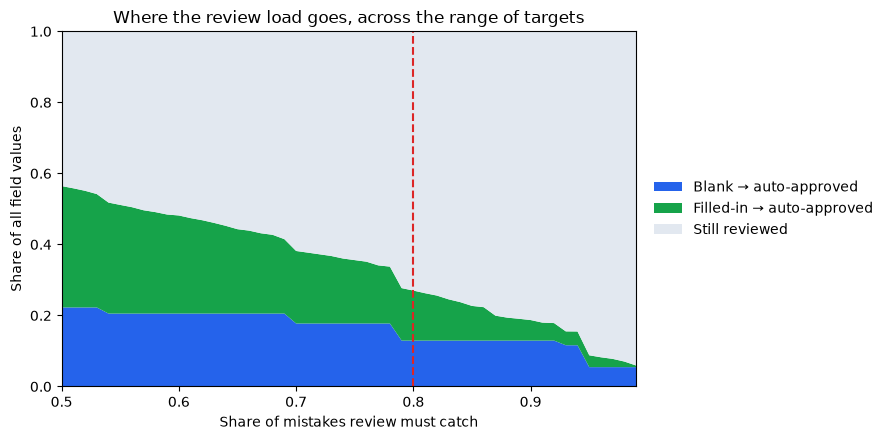

In [6]:
sweep = calib.savings_sweep(base_policies, train, start=0.50, end=0.99, step=0.01)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.stackplot(
    sweep["target"],
    sweep["null_savings_pct"],
    sweep["lr_savings_pct"],
    sweep["hitl_load"],
    labels=["Blank → auto-approved", "Filled-in → auto-approved", "Still reviewed"],
    colors=["#2563eb", "#16a34a", "#e2e8f0"],
)
ax.axvline(TARGET, color="#dc2626", linestyle="--", linewidth=1.5)
ax.set_xlim(0.50, 0.99)
ax.set_ylim(0, 1)
ax.set_xlabel("Share of mistakes review must catch")
ax.set_ylabel("Share of all field values")
ax.set_title("Where the review load goes, across the range of targets")
ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), frameon=False)
fig.tight_layout()
plt.show()


## 3. Save the calibration table

The table above is the whole deliverable. Write it to CSV — this file, and
nothing else, is what production needs.


In [7]:
TABLE_PATH = f"data/calibration_table_{round(TARGET * 100)}pct.csv"

saved = calib.save_calibration_table(policies, TABLE_PATH)
print(f"wrote {saved}  ({saved.stat().st_size:,} bytes)\n")
print(saved.read_text().splitlines()[0])


wrote data\calibration_table_80pct.csv  (1,273 bytes)

field_name,filled_decision,cutoff,score_mode,lr_coef,lr_intercept,blank_decision,target_catch_rate,min_null_precision,calibrated_at,why


## 4. Deploy it: load the table and route unseen documents

This is the production path. Load the CSV back — the fitted objects and the
labeled data are gone, only the table remains — and route the held-out test
documents through it. Copy `calibration.py` and `acu_calibrator.py` alongside
the CSV and these two calls are your whole inference-time integration.

Read `stp_error_rate` per field, not just the portfolio figure below it. The
dial controls how many mistakes review catches; it does not cap how wrong the
auto-approved values are, and that rate varies widely by field.


In [8]:
shipped = calib.load_calibration_table(TABLE_PATH)

routed = calib.route_frame(data, shipped, split="test")
held_out, totals = calib.held_out_metrics(routed)

print(f"On {routed['document_id'].nunique()} unseen documents "
      f"({totals['field_values']:,} values):")
print(f"  auto-approved:            {totals['auto_approve_rate']:.1%}")
print(f"  mistakes caught:          {totals['catch_rate']:.1%}  (asked for {TARGET:.0%})")
print(f"  mistakes slipped through: {totals['stp_error_rate']:.1%} of auto-approved values")

held_out.round(3)


On 200 unseen documents (2,641 values):
  auto-approved:            28.2%
  mistakes caught:          85.4%  (asked for 80%)
  mistakes slipped through: 9.7% of auto-approved values


,field_name,n_observations,auto_approved,auto_approve_rate,mistakes_slipped_through,stp_error_rate,total_mistakes,mistakes_caught,catch_rate
0,menu.name,547,125,0.229,35,0.280,163,128,0.785
1,menu.price,547,135,0.247,18,0.133,90,72,0.800
2,menu.quantity,547,0,0.000,0,NaN,105,105,1.000
3,other_adjustment,200,180,0.900,4,0.022,23,19,0.826
4,service_price,200,170,0.850,6,0.035,23,17,0.739
5,subtotal_price,200,78,0.390,5,0.064,39,34,0.872
6,tax_price,200,0,0.000,0,NaN,32,32,1.000
7,total_price,200,58,0.290,4,0.069,17,13,0.765


In [9]:
# Every decision is explainable after the fact, and checkable against ground truth.
audit = (
    routed.groupby("route_reason")
    .agg(values=("is_correct", "size"),
         sent_to_review=("route_to_hitl", "sum"),
         mistakes=("is_correct", lambda s: int((~s.astype(bool)).sum())),
         mistakes_slipped=("stp_error", "sum"))
    .sort_values("values", ascending=False)
)
audit


,values,sent_to_review,mistakes,mistakes_slipped
route_reason,,,,
raw_below_threshold,1058,1058,238,0
non_null_uncalibrated,564,564,109,0
raw_above_threshold,380,0,68,68
null_policy_stp,366,0,4,4
null_policy_review,273,273,73,0


Does the dial behave like a dial? Sweep every target, rebuild on training
documents only, and measure what the untouched test documents actually got.

The green line is the one the target governs. It tracks the diagonal but sits
a little under it: each cutoff is the most aggressive one that cleared the
target on the training split, so there is no margin to absorb the shift to
unseen documents. The amber line runs higher only because fully reviewed
fields catch everything.


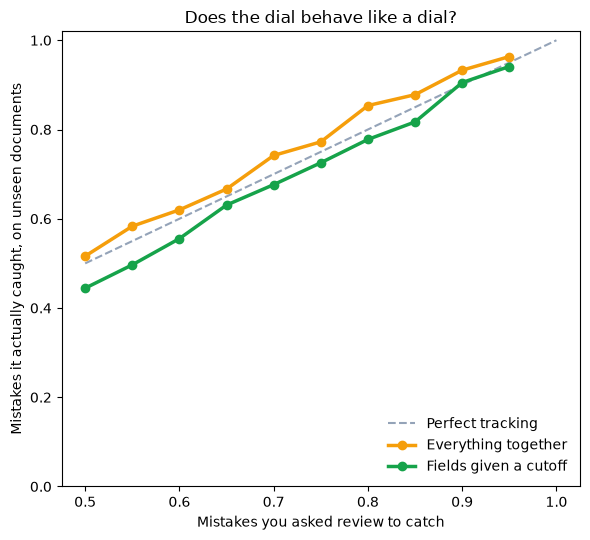

In [10]:
tracking = calib.coverage_tracking(base_policies, data, split="test", step=0.05)

fig, ax = plt.subplots(figsize=(6, 5.5))
ax.plot([0.5, 1.0], [0.5, 1.0], "--", color="#94a3b8", label="Perfect tracking")
ax.plot(tracking["target"], tracking["overall_catch"], "o-",
        color="#f59e0b", linewidth=2.5, label="Everything together")
ax.plot(tracking["target"], tracking["calibrated_catch"], "o-",
        color="#16a34a", linewidth=2.5, label="Fields given a cutoff")
ax.set_xlabel("Mistakes you asked review to catch")
ax.set_ylabel("Mistakes it actually caught, on unseen documents")
ax.set_ylim(0, 1.02)
ax.legend(frameon=False, loc="lower right")
ax.set_title("Does the dial behave like a dial?")
fig.tight_layout()
plt.show()


## 5. Run it on your own data

Everything above only needed a table with these six columns — one row per
extracted field value:

| column | meaning |
| --- | --- |
| `document_id` | which document the value came from |
| `split` | `train` \| `test` |
| `field_name` | which field this value belongs to |
| `extracted_value` | what CU returned (`None` if nothing) |
| `confidence` | CU's confidence for that value, 0–1 |
| `is_correct` | did it match ground truth? |

`matching.add_is_correct(frame)` fills in that last column for you, comparing
extractions to ground truth with per-field normalization. Build the frame from
your own CU output, then re-run this notebook from the top with
`data = calib.load_canonical_file("my_data.parquet")`.


In [11]:
# Sketch: replace this with your own CU output paired against ground truth.
my_data = pd.DataFrame(
    [
        {
            "document_id": "invoice-0001",
            "split": "train",
            "field_name": "total_amount",
            "extracted_value": "1,240.00",
            "confidence": 0.91,
            "is_correct": True,
        },
    ]
)

# base_policies = calib.fit_base_policies(my_data, split="train")
# policies = calib.select_policies(base_policies, 0.80)
# held_out, totals = calib.held_out_metrics(calib.route_frame(my_data, policies, split="test"))

my_data


,document_id,split,field_name,extracted_value,confidence,is_correct
0,invoice-0001,train,total_amount,"1,240.00",0.91,True


### Adding a second predictor later

By default the lab thresholds CU confidence directly. Switching to
`score_mode="logistic"` first maps confidence to `P(correct)`:

```python
base_policies = calib.fit_base_policies(data, split="train", score_mode="logistic")
```

With confidence as the only predictor, both modes rank values identically —
every metric and routing decision matches, only the units of the exported
cutoff change. The logistic form is what you extend once you have a second
predictor of correctness (page quality, vendor, field length, cross-field
consistency checks). Try the switch and confirm the numbers do not move.
